# Auto-Sklearn for Regression
In this section, we will use Auto-Sklearn to discover a model for the auto House Price Prediction dataset.


## Auto-Sklearn
The Auto-Sklearn architecture is composed of 3 phases: meta-learning, bayesian optimization, ensemble selection. The key idea of the meta-learning phase is to reduce the space search by learning from models that performed well on similar datasets. Right after, the bayesian optimization phase takes the space search created in the meta-learning step and creates bayesian models for finding the optimal pipeline configuration. Finally, an ensemble selection model is created by reusing the most accurate models found in the bayesian optimization step. In Figure 2 it’s described the Auto-Sklearn architectur

![](https://miro.medium.com/max/1000/1*w8qIzewO97qdqmiZi69Maw.jpeg)

## Data Description
The data set describing the sale of individual residential property in Ames, Iowafrom 2006 to 2010. The data set contains 2930 observations and a large number of explanatory variables (23 nominal, 23 ordinal, 14 discrete, and 20 continuous) involved in assessing home values.

If need more information in this link

(Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project)

[Paper ](http://jse.amstat.org/v19n3/decock.pdf)




### File descriptions
* train.csv - the training set
* test.csv - the test set
* data_description.txt - full description of each column, originally prepared by Dean De Cock but lightly edited to match the column names used here
* sample_submission.csv - a benchmark submission from a linear regression on year and month of sale, lot square footage, and number of bedrooms


### Dataset



[Link](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview)

In [1]:
pip install auto-sklearn

     |████████████████████████████████| 6.1 MB 5.5 MB/s 
     |████████████████████████████████| 4.0 MB 8.7 MB/s 
     |████████████████████████████████| 258 kB 11.7 MB/s 
  Created wheel for auto-sklearn: filename=auto_sklearn-0.12.5-py3-none-any.whl size=6367617 sha256=124da00df5ede983f030348025f902309bb14ceaf52390b7c70abf8ae4f6a758
  Stored in directory: /root/.cache/pip/wheels/0d/54/71/61cc11f67d479fbaee740c1aab8d6bde70b202ed0340b12efb
  Created wheel for pynisher: filename=pynisher-0.6.4-py3-none-any.whl size=7043 sha256=c5e2f025f6fd9ff3440fa760a3d4add2f5e073644df4887f3fd820a84882e623
  Stored in directory: /root/.cache/pip/wheels/42/71/95/7555ec3253e1ba8add72ae5febf1b015d297f3b73ba296d6f6
  Created wheel for smac: filename=smac-0.13.1-py3-none-any.whl size=252176 sha256=26d6a36f42f89b0fc2c984f01cb05cb36aac06b8bb7e29fc696887b9b6825d3d
  Stored in directory: /root/.cache/pip/wheels/35/b9/6b/17b5f3d627b1be6cdcc5357f797bd9e4ea8cbae3d1ff00e621
  Created wheel for lazy-import: filename

In [2]:
# Import Lab
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from autosklearn.regression import AutoSklearnRegressor
from autosklearn.metrics import mean_absolute_error as auto_mean_absolute_error

/opt/conda/lib/python3.7/site-packages/pyparsing.py:3190: FutureWarning: Possible set intersection at position 3
  self.re = re.compile(self.reString)


In [3]:
df_train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
df_test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

In [4]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [9]:
df_train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [10]:
df_test.isna().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [11]:
# Convert strings to categories with using pandas API

for label, content in df_train.items():
    if pd.api.types.is_string_dtype(content):
        print(label)

MSZoning
Street
Alley
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
PoolQC
Fence
MiscFeature
SaleType
SaleCondition


In [12]:
for label, content in df_train.items():
    if pd.api.types.is_string_dtype(content):
        df_train[label] = content.astype('category').cat.as_ordered()

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   category
 6   Alley          91 non-null     category
 7   LotShape       1460 non-null   category
 8   LandContour    1460 non-null   category
 9   Utilities      1460 non-null   category
 10  LotConfig      1460 non-null   category
 11  LandSlope      1460 non-null   category
 12  Neighborhood   1460 non-null   category
 13  Condition1     1460 non-null   category
 14  Condition2     1460 non-null   category
 15  BldgType       1460 non-null   category
 16  HouseStyle     1460 non-null   category
 17  OverallQual    1460 non-null   in

In [14]:
df_train.isnull().sum()/len(df_train)

Id               0.000000
MSSubClass       0.000000
MSZoning         0.000000
LotFrontage      0.177397
LotArea          0.000000
                   ...   
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
SalePrice        0.000000
Length: 81, dtype: float64

In [15]:
for label, content in df_train.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

Id
MSSubClass
LotFrontage
LotArea
OverallQual
OverallCond
YearBuilt
YearRemodAdd
MasVnrArea
BsmtFinSF1
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
TotRmsAbvGrd
Fireplaces
GarageYrBlt
GarageCars
GarageArea
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
MiscVal
MoSold
YrSold
SalePrice


In [16]:
for label, content in df_train.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

LotFrontage
MasVnrArea
GarageYrBlt


In [17]:
# Fill numeric rows with median()

for label, content in df_train.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            df_train[label+ '_is_missing'] = pd.isnull(content)
            df_train[label] = content.fillna(content.median())

In [18]:
for label, content in df_train.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

In [19]:
for label, content in df_train.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

MSZoning
Street
Alley
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
PoolQC
Fence
MiscFeature
SaleType
SaleCondition


In [20]:
for label, content in df_train.items():
    if not pd.api.types.is_numeric_dtype(content):
        df_train[label + '_is_missing'] = pd.isnull(content)
        df_train[label] = pd.Categorical(content).codes+1

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='SalePrice'>

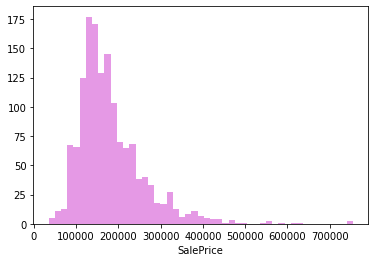

In [21]:
sns.distplot(df_train['SalePrice'], kde=False, color='m')

<AxesSubplot:xlabel='SalePrice', ylabel='Density'>

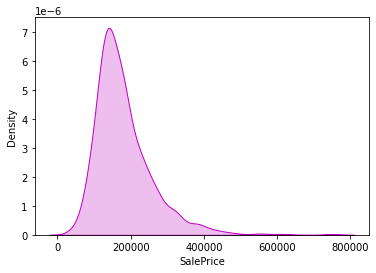

In [22]:
sns.kdeplot(df_train['SalePrice'], shade=True, color='m')

In [23]:
# split into train and test sets
X = df_train.drop('SalePrice', axis=1)
y = df_train['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(978, 126)
(482, 126)
(978,)
(482,)


In [25]:
# Auto-Sklearn Initialization
model = AutoSklearnRegressor(time_left_for_this_task=300, 
                              per_run_time_limit=30, 
                              ensemble_size=1, 
                              initial_configurations_via_metalearning=0)
# Init training
model.fit(X_train, y_train)

AutoSklearnRegressor(ensemble_size=1, initial_configurations_via_metalearning=0,
                     per_run_time_limit=30, time_left_for_this_task=300)

In [26]:
y_hat =model.predict(X_test)

In [27]:
y_hat

array([209453.       , 145988.75     , 118067.1328125,  81200.       ,
       148140.       , 316252.71875  , 323858.9375   , 149758.671875 ,
       219500.       , 223671.234375 , 161200.       ,  81900.       ,
       206356.984375 , 316906.5      , 240996.796875 , 110291.6640625,
       124069.484375 , 147907.140625 , 207875.       , 130083.3359375,
       132655.59375  , 124500.       , 268184.21875  , 314813.       ,
       106335.       , 175722.21875  , 132018.75     , 195184.265625 ,
       442750.       , 131760.8125   , 135348.546875 , 123666.6640625,
       124641.8359375, 102190.90625  , 147250.       , 379317.28125  ,
       119166.6640625,  89576.921875 , 234666.671875 , 118972.15625  ,
       143417.671875 , 145900.       , 107257.3203125, 122900.       ,
       180857.9375   , 174363.40625  , 150840.       , 186291.078125 ,
       254061.015625 , 237400.       , 109535.296875 , 301333.34375  ,
       115970.       , 250000.       , 198600.       , 107142.390625 ,
      

In [28]:
y_test

258     231500
267     179500
288     122000
649      84500
1233    142000
         ...  
1115    318000
825     385000
937     253000
1387    136000
764     270000
Name: SalePrice, Length: 482, dtype: int64

In [29]:
# summarize
print(model.sprint_statistics())

auto-sklearn results:
  Dataset name: 1689ba74-a11a-11eb-8013-0242ac130202
  Metric: r2
  Best validation score: 0.878493
  Number of target algorithm runs: 26
  Number of successful target algorithm runs: 25
  Number of crashed target algorithm runs: 0
  Number of target algorithms that exceeded the time limit: 1
  Number of target algorithms that exceeded the memory limit: 0



In [30]:
model.score(X_test, y_test)

0.8776112962401516

In [31]:
# evaluate best model
y_hat = model.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
print("MAE: %.3f" % mae)

MAE: 20090.274


In [32]:
print(model.show_models())

[(1.000000, SimpleRegressionPipeline({'data_preprocessing:categorical_transformer:categorical_encoding:__choice__': 'one_hot_encoding', 'data_preprocessing:categorical_transformer:category_coalescence:__choice__': 'no_coalescense', 'data_preprocessing:numerical_transformer:imputation:strategy': 'most_frequent', 'data_preprocessing:numerical_transformer:rescaling:__choice__': 'quantile_transformer', 'feature_preprocessor:__choice__': 'select_percentile_regression', 'regressor:__choice__': 'adaboost', 'data_preprocessing:numerical_transformer:rescaling:quantile_transformer:n_quantiles': 319, 'data_preprocessing:numerical_transformer:rescaling:quantile_transformer:output_distribution': 'normal', 'feature_preprocessor:select_percentile_regression:percentile': 17.463822022352954, 'feature_preprocessor:select_percentile_regression:score_func': 'mutual_info', 'regressor:adaboost:learning_rate': 0.03832499764647972, 'regressor:adaboost:loss': 'exponential', 'regressor:adaboost:max_depth': 8, '